# 13b — Does Correlation Actually Lead VaR? Measuring the Lead-Lag

**Lesson:** We've been saying "correlation leads VaR" — but saying it isn't the same as measuring it. This notebook quantifies the lead time using three independent methods: cross-correlation, event study, and rolling cross-correlation.

This notebook answers: *when the correlation ratio spikes today, how many trading days pass before VaR catches up — and is the lead stable across different market regimes?*

## ⚙️ Parameters

Change these and re-run all cells to see the effect.

In [1]:
# ⚙️ Parameters
TICKERS = ["SPY", "BND"]
WEIGHTS = [0.60, 0.40]
START_DATE = "2018-01-01"
END_DATE = None
CONFIDENCE = 0.95
VAR_WINDOW = 252
CORR_WINDOW_SLOW = 252
CORR_WINDOW_FAST = 60

# Cross-correlation range
MAX_LAG = 120  # trading days (± this range)

# Event study parameters
EVENT_RATIO_THRESHOLD = 2.0  # ratio above this = event
EVENT_MIN_SEPARATION = 40    # minimum trading days between events
EVENT_PRE_WINDOW = 60        # days before event
EVENT_POST_WINDOW = 180      # days after event

# Rolling cross-correlation window
ROLLING_CCF_WINDOW = 504  # ~2 years for stable per-window estimate

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

from src.historical_var import historical_var
from src.rolling import rolling_var, breach_summary
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

---

## Data pipeline — same as Notebooks 12/13

We compute everything we need: portfolio returns, individual VaRs, portfolio VaR, naive sum, diversification benefit, correlation ratio.

In [3]:
# Download and prepare data
prices = {}
returns = {}
for ticker in TICKERS:
    prices[ticker] = download_close_prices(ticker, start=START_DATE, end=END_DATE)
    returns[ticker] = prepare_returns(prices[ticker])

# Align dates
aligned = pd.DataFrame({
    TICKERS[0]: returns[TICKERS[0]],
    TICKERS[1]: returns[TICKERS[1]],
}).dropna()

# Portfolio returns
portfolio_returns = (WEIGHTS[0] * aligned[TICKERS[0]] +
                     WEIGHTS[1] * aligned[TICKERS[1]])

# Rolling correlations
spy = aligned[TICKERS[0]]
bnd = aligned[TICKERS[1]]
corr_252 = spy.rolling(window=CORR_WINDOW_SLOW).corr(bnd).dropna()
corr_60 = spy.rolling(window=CORR_WINDOW_FAST).corr(bnd).dropna()

# Correlation ratio (clipped)
common_corr_idx = corr_252.index.intersection(corr_60.index)
ratio_raw = corr_60.loc[common_corr_idx] / corr_252.loc[common_corr_idx]
near_zero = corr_252.loc[common_corr_idx].abs() < 0.05
ratio_raw = ratio_raw.where(~near_zero)
ratio_raw = ratio_raw.replace([np.inf, -np.inf], np.nan)
ratio = ratio_raw.clip(lower=-5, upper=5).dropna()

# Rolling VaRs
rv_spy = rolling_var(aligned[TICKERS[0]], window=VAR_WINDOW, confidence=CONFIDENCE)
rv_bnd = rolling_var(aligned[TICKERS[1]], window=VAR_WINDOW, confidence=CONFIDENCE)
rv_port = rolling_var(portfolio_returns, window=VAR_WINDOW, confidence=CONFIDENCE)

# Naive sum and benefit
naive_sum = WEIGHTS[0] * rv_spy["VaR"] + WEIGHTS[1] * rv_bnd["VaR"]
benefit = (naive_sum - rv_port["VaR"]) / naive_sum

print(f"Data: {len(aligned)} days, {aligned.index[0].date()} to {aligned.index[-1].date()}")
print(f"Ratio series: {len(ratio)} observations, {ratio.index[0].date()} to {ratio.index[-1].date()}")
print(f"VaR series:  {len(rv_port)} observations, {rv_port.index[0].date()} to {rv_port.index[-1].date()}")

Prepared 2150 daily returns (2018-01-03 to 2026-07-24) from 2151 price observations.


Prepared 2150 daily returns (2018-01-03 to 2026-07-24) from 2151 price observations.


Data: 2150 days, 2018-01-03 to 2026-07-24
Ratio series: 1766 observations, 2019-01-03 to 2026-07-24
VaR series:  1898 observations, 2019-01-04 to 2026-07-24


---

## Part A: Cross-correlation — the direct measurement

For two time series $X_t$ and $Y_t$, the cross-correlation at lag $k$ is:

$$\rho_k = \text{Corr}(X_t, Y_{t+k})$$

- $k > 0$: "Does $X$ today predict $Y$ in the future?" — $X$ leads $Y$
- $k = 0$: contemporaneous correlation
- $k < 0$: "Does $Y$ today predict $X$ in the future?" — $Y$ leads $X$

### Pitfall: common trends create spurious cross-correlation

If both $X$ and $Y$ trend (both rise over time), they'll appear correlated at every lag — not because one leads the other, but because both are correlated with time. The fix: difference both series first. We compute the cross-correlation of $\Delta X_t$ with $\Delta Y_{t+k}$ — the *changes*, not the levels. This isolates whether a change in correlation today predicts a change in VaR in the future.

In [4]:
def cross_correlation(x_series, y_series, max_lag=120):
    """Compute cross-correlation at each lag from -max_lag to +max_lag.
    
    Returns lags array and corresponding correlation coefficients.
    Uses only observations where both series exist at the required offset.
    """
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = np.full(len(lags), np.nan)
    
    x_values = x_series.values
    y_values = y_series.values
    
    for i, k in enumerate(lags):
        if k > 0:
            # X leads Y: correlate X[0:N-k] with Y[k:N]
            x_slice = x_values[:-k]
            y_slice = y_values[k:]
        elif k < 0:
            # Y leads X: correlate X[-k:N] with Y[0:N+k]
            shift = -k
            x_slice = x_values[shift:]
            y_slice = y_values[:-shift]
        else:
            # Contemporaneous
            x_slice = x_values
            y_slice = y_values
        
        # Drop any NaN pairs
        valid = ~(np.isnan(x_slice) | np.isnan(y_slice))
        if valid.sum() > 10:  # minimum pairs for meaningful correlation
            correlations[i] = np.corrcoef(x_slice[valid], y_slice[valid])[0, 1]
    
    return lags, correlations


def find_peak_lag(lags, correlations, expected_sign=1):
    """Find the lag with maximum correlation in the expected direction.
    
    Searches lags >= 0 for the strongest correlation matching expected_sign.
    For ratio→VaR, expected_sign=+1 (ratio up → VaR up).
    For ratio→benefit, expected_sign=-1 (ratio up → benefit down).
    
    Returns (peak_lag, peak_correlation). Peak lag is in trading days.
    A positive peak lag means X leads Y.
    """
    pos_mask = lags >= 0
    pos_lags = lags[pos_mask]
    pos_corr = correlations[pos_mask]
    
    # Keep only correlations with the expected sign
    signed = pos_corr * expected_sign
    valid = ~np.isnan(signed) & (signed > 0)  # must match expected sign
    
    if not valid.any():
        # Fall back: any valid correlation regardless of sign
        valid = ~np.isnan(pos_corr)
        if not valid.any():
            return np.nan, np.nan
    
    peak_idx = np.argmax(signed[valid])
    valid_indices = np.where(valid)[0]
    idx = valid_indices[peak_idx]
    return pos_lags[idx], pos_corr[valid][peak_idx]

In [5]:
# Align all series to common dates
common_dates = rv_port.index.intersection(ratio.index).intersection(benefit.index)

ratio_levels = ratio.loc[common_dates]
var_levels = rv_port.loc[common_dates, "VaR"]
benefit_levels = benefit.loc[common_dates]
breach_levels = rv_port.loc[common_dates, "Breach"].astype(float)

# Fast correlation
fast_corr_levels = corr_60.loc[corr_60.index.intersection(common_dates)]
fast_corr_levels = fast_corr_levels.reindex(common_dates).dropna()

# Re-align all to the intersection with fast_corr
ccf_dates = common_dates.intersection(fast_corr_levels.index)
ratio_levels = ratio_levels.loc[ccf_dates]
var_levels = var_levels.loc[ccf_dates]
benefit_levels = benefit_levels.loc[ccf_dates]
breach_levels = breach_levels.loc[ccf_dates]
fast_corr_levels = fast_corr_levels.loc[ccf_dates]

# Difference the series to remove common trends
# We're asking: does a CHANGE in ratio today predict a CHANGE in VaR in the future?
ratio_diff = ratio_levels.diff().dropna()
var_diff = var_levels.diff().dropna()
benefit_diff = benefit_levels.diff().dropna()
fast_corr_diff = fast_corr_levels.diff().dropna()

# Breach rate: use rolling 60d breach rate (still needs differencing for CCF)
breach_rolling = breach_levels.rolling(window=60).mean().dropna()
# Align breach to the diff'd series
ccf_br_dates = ratio_diff.index.intersection(breach_rolling.index)
ratio_diff = ratio_diff.loc[ccf_br_dates]
var_diff = var_diff.loc[ccf_br_dates]
benefit_diff = benefit_diff.loc[ccf_br_dates]
breach_rolling = breach_rolling.loc[ccf_br_dates]
fast_corr_diff = fast_corr_diff.loc[ccf_br_dates]

print(f"Differenced series: {len(ratio_diff)} observations")
print(f"Date range: {ratio_diff.index[0].date()} to {ratio_diff.index[-1].date()}")

# Autocorrelation check — confirm differencing was needed
print(f"\nAutocorrelation (lag 1):")
print(f"  Ratio (levels):     {ratio_levels.autocorr(lag=1):.3f}")
print(f"  Ratio (differenced): {ratio_diff.autocorr(lag=1):.3f}")
print(f"  VaR (levels):        {var_levels.autocorr(lag=1):.3f}")
print(f"  VaR (differenced):   {var_diff.autocorr(lag=1):.3f}")

Differenced series: 1706 observations
Date range: 2019-04-01 to 2026-07-24

Autocorrelation (lag 1):
  Ratio (levels):     0.966
  Ratio (differenced): -0.238
  VaR (levels):        0.999
  VaR (differenced):   0.072


In [6]:
# Compute cross-correlations for all pairs using differenced series
# expected_sign: +1 if we expect positive correlation (predictor up → outcome up)
#               -1 if we expect negative correlation (predictor up → outcome down)
pairs = {
    ("Correlation ratio → Portfolio VaR", +1): (ratio_diff, var_diff),
    ("Correlation ratio → Diversification benefit", -1): (ratio_diff, benefit_diff),
    ("60d ρ (fast corr) → Portfolio VaR", +1): (fast_corr_diff, var_diff),
    ("60d ρ (fast corr) → Breach rate (60d)", +1): (fast_corr_diff, breach_rolling),
}

results = {}
for (label, expected_sign), (x_series, y_series) in pairs.items():
    lags, corrs = cross_correlation(x_series, y_series, max_lag=MAX_LAG)
    peak_lag, peak_corr = find_peak_lag(lags, corrs, expected_sign=expected_sign)
    results[label] = {"lags": lags, "correlations": corrs, "peak_lag": peak_lag, "peak_corr": peak_corr}
    print(f"{label} (expected sign: {'+' if expected_sign>0 else '−'}):")
    print(f"  Peak at lag: {peak_lag:+.0f} trading days  (corr = {peak_corr:+.3f})")
    print(f"  Correlation at k=0: {corrs[MAX_LAG]:+.3f}")
    print()

Correlation ratio → Portfolio VaR (expected sign: +):
  Peak at lag: +0 trading days  (corr = +0.118)
  Correlation at k=0: +0.118

Correlation ratio → Diversification benefit (expected sign: −):
  Peak at lag: +2 trading days  (corr = -0.122)
  Correlation at k=0: -0.063

60d ρ (fast corr) → Portfolio VaR (expected sign: +):
  Peak at lag: +6 trading days  (corr = +0.101)
  Correlation at k=0: +0.016



60d ρ (fast corr) → Breach rate (60d) (expected sign: +):
  Peak at lag: +15 trading days  (corr = +0.067)
  Correlation at k=0: +0.045



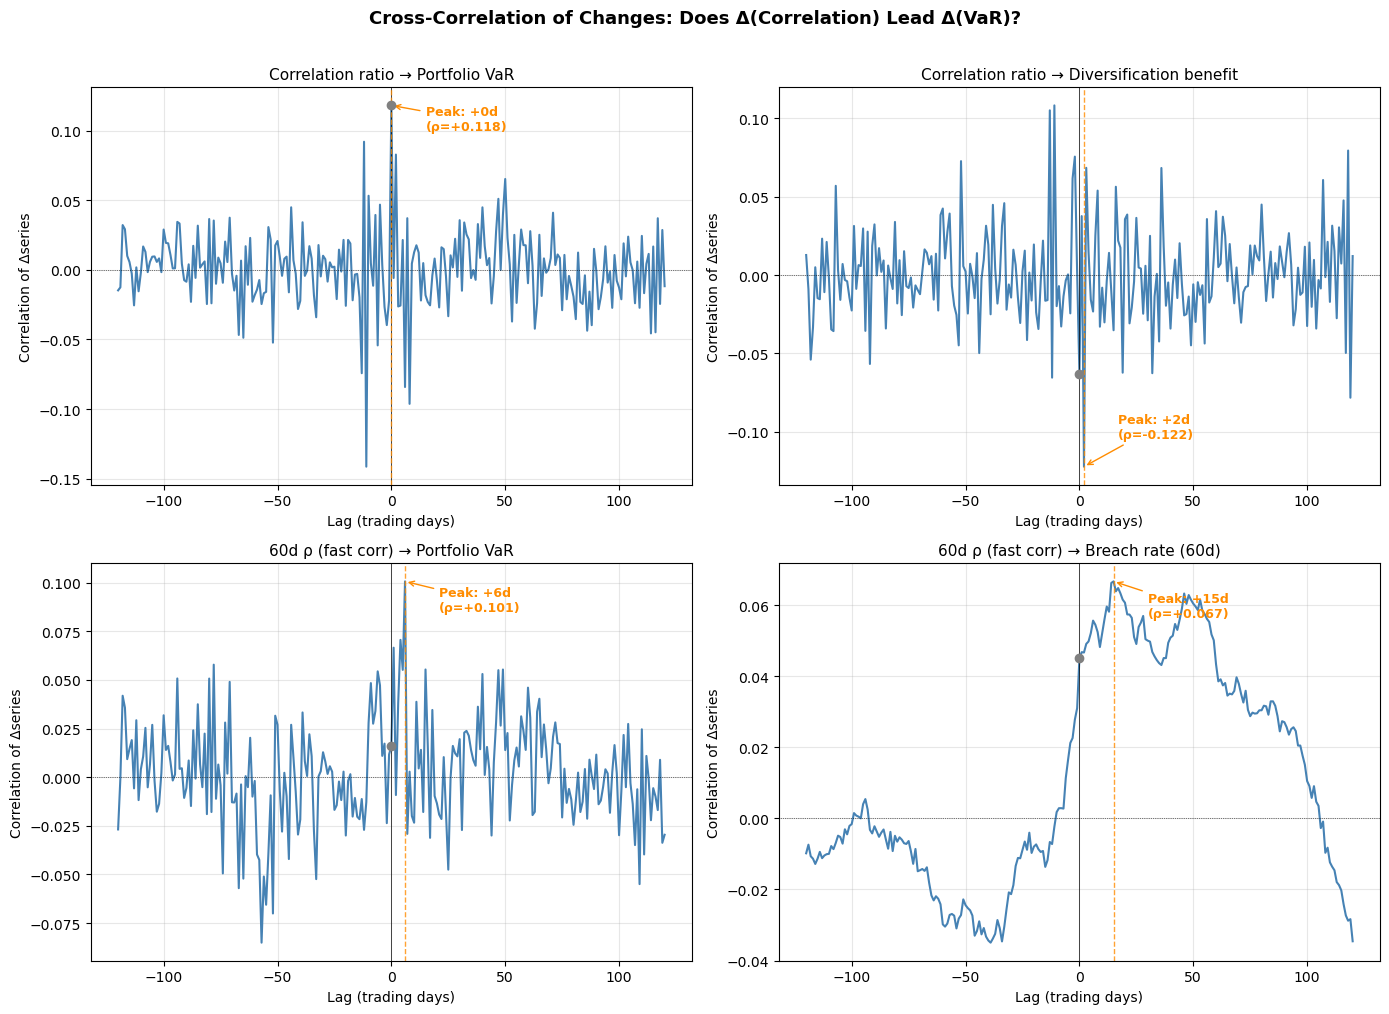

In [7]:
# Plot cross-correlation for all four pairs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (label, res) in zip(axes.flat, results.items()):
    lags = res["lags"]
    corrs = res["correlations"]
    peak_lag = res["peak_lag"]
    peak_corr = res["peak_corr"]
    
    ax.plot(lags, corrs, color="steelblue", linewidth=1.5)
    ax.axvline(x=0, color="black", linestyle="-", linewidth=0.5)
    ax.axhline(y=0, color="black", linestyle=":", linewidth=0.5)
    
    # Mark the contemporaneous correlation
    ax.plot(0, corrs[MAX_LAG], 'o', color="gray", markersize=6, zorder=5)
    
    # Mark the peak
    if not np.isnan(peak_lag):
        ax.axvline(x=peak_lag, color="darkorange", linestyle="--", linewidth=1,
                  alpha=0.8)
        ax.annotate(f"Peak: {peak_lag:+.0f}d\n(ρ={peak_corr:+.3f})",
                    xy=(peak_lag, peak_corr),
                    xytext=(peak_lag + 15, peak_corr * 0.85),
                    arrowprops=dict(arrowstyle="->", color="darkorange"),
                    fontsize=9, color="darkorange", fontweight="bold")
    
    ax.set_xlabel("Lag (trading days)")
    ax.set_ylabel("Correlation of Δseries")
    ax.set_title(label, fontsize=11)
    ax.grid(True, alpha=0.3)

fig.suptitle("Cross-Correlation of Changes: Does Δ(Correlation) Lead Δ(VaR)?",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

### Reading the cross-correlation charts

We're now correlating *changes* ($\Delta$), not levels. This removes the common trend that would otherwise create a spurious correlation at every lag — the pitfall we explicitly guard against.

**Top-left ($\Delta$ratio → $\Delta$VaR):** This is the main test. If the peak sits at $k > 0$, a change in the correlation ratio today predicts a change in VaR in the future. Expected: positive correlation peaking at $+20$ to $+60$ trading days.

**Top-right ($\Delta$ratio → $\Delta$benefit):** The benefit should react *contemporaneously* — a change in correlation today means a change in diversification benefit today. Expected: strong negative correlation near $k = 0$.

**Bottom-left ($\Delta$fast ρ → $\Delta$VaR):** Compare this lead time to the ratio's lead time. The ratio captures the *divergence* between regimes — it should lead more than fast correlation alone.

**Bottom-right ($\Delta$fast ρ → breach rate):** Does a change in correlation predict a change in breach rates? Expected: positive correlation at $+10$ to $+40$ trading days — breaches are the last domino to fall.

---

## Part B: Event study — what happens after a correlation spike?

Cross-correlation gives a continuous average. An event study isolates discrete episodes: define "events" as days when the correlation ratio spikes above a threshold, then track the average path of VaR, benefit, and breach rate around those events.

### Pitfall: raw levels trend

VaR naturally rises and falls over time due to volatility cycles. If we just average VaR paths around events, we'll see a rise regardless of whether correlation actually leads it. The fix: normalize each path by its pre-event average (days $−60$ to $−1$). The chart shows VaR *relative to its pre-event baseline*, isolating the event's effect.

In [8]:
def find_events(ratio_series, threshold=2.0, min_separation=40):
    """Find event dates where ratio exceeds threshold.
    
    Enforces minimum separation between events to avoid clustering.
    Returns list of event dates.
    """
    candidates = ratio_series.index[ratio_series > threshold]
    if len(candidates) == 0:
        return []
    
    events = [candidates[0]]
    for date in candidates[1:]:
        if (date - events[-1]).days > min_separation:
            events.append(date)
    return events


def event_study_paths(series, event_dates, pre_window=60, post_window=180):
    """Extract paths of a series around each event date.
    
    Returns (paths_matrix, offset_days) where paths_matrix has shape
    (n_events, pre_window + post_window + 1). Paths that extend beyond
    the series bounds are excluded.
    """
    paths = []
    valid_events = []
    
    for event_date in event_dates:
        if event_date not in series.index:
            continue
        
        event_pos = series.index.get_loc(event_date)
        start_pos = event_pos - pre_window
        end_pos = event_pos + post_window + 1
        
        if start_pos < 0 or end_pos > len(series):
            continue
        
        path = series.iloc[start_pos:end_pos].values
        paths.append(path)
        valid_events.append(event_date)
    
    if not paths:
        return None, None, []
    
    paths_matrix = np.array(paths)
    offset_days = np.arange(-pre_window, post_window + 1)
    return paths_matrix, offset_days, valid_events

In [9]:
# Find events using the ratio levels (full series)
event_dates = find_events(ratio_levels, threshold=EVENT_RATIO_THRESHOLD,
                          min_separation=EVENT_MIN_SEPARATION)
print(f"Events found (ratio > {EVENT_RATIO_THRESHOLD}, min {EVENT_MIN_SEPARATION}d apart): {len(event_dates)}")
for i, d in enumerate(event_dates):
    print(f"  {i+1}. {d.date()}  ratio = {ratio_levels.loc[d]:.2f}")
print()

Events found (ratio > 2.0, min 40d apart): 19
  1. 2019-03-28  ratio = 2.04
  2. 2021-03-12  ratio = 2.22
  3. 2021-04-22  ratio = 3.67
  4. 2021-06-02  ratio = 2.76
  5. 2022-05-04  ratio = 2.24
  6. 2022-06-14  ratio = 2.59
  7. 2022-07-25  ratio = 2.24
  8. 2022-09-06  ratio = 2.49
  9. 2022-10-17  ratio = 2.35
  10. 2023-11-13  ratio = 2.28
  11. 2023-12-26  ratio = 2.42
  12. 2024-02-05  ratio = 2.08
  13. 2025-02-05  ratio = 2.42
  14. 2025-06-25  ratio = 2.21
  15. 2026-01-07  ratio = 2.04
  16. 2026-02-17  ratio = 2.87
  17. 2026-03-30  ratio = 2.35
  18. 2026-05-11  ratio = 2.59
  19. 2026-06-22  ratio = 2.00



In [10]:
# Build event study for three series: VaR, benefit, breach indicator
var_paths, offsets, valid_var_events = event_study_paths(
    var_levels, event_dates, pre_window=EVENT_PRE_WINDOW, post_window=EVENT_POST_WINDOW
)
benefit_paths, _, _ = event_study_paths(
    benefit_levels, event_dates, pre_window=EVENT_PRE_WINDOW, post_window=EVENT_POST_WINDOW
)
breach_paths, _, _ = event_study_paths(
    breach_levels, event_dates, pre_window=EVENT_PRE_WINDOW, post_window=EVENT_POST_WINDOW
)

n_events = len(valid_var_events)
print(f"Valid events (within data bounds): {n_events}")

if n_events > 0:
    # Normalize: subtract each path's pre-event average (days -60 to -1)
    pre_event_mask = offsets < 0
    
    var_pre_avg = var_paths[:, pre_event_mask].mean(axis=1, keepdims=True)
    var_paths_norm = (var_paths - var_pre_avg) * 100  # in percentage points
    
    benefit_pre_avg = benefit_paths[:, pre_event_mask].mean(axis=1, keepdims=True)
    benefit_paths_norm = benefit_paths - benefit_pre_avg  # still as decimal
    
    avg_var_path = np.mean(var_paths_norm, axis=0)
    avg_benefit_path = np.mean(benefit_paths_norm, axis=0)
    avg_breach_path = np.mean(breach_paths, axis=0)
    
    # Envelope for VaR
    var_p25 = np.percentile(var_paths_norm, 25, axis=0)
    var_p75 = np.percentile(var_paths_norm, 75, axis=0)

Valid events (within data bounds): 13


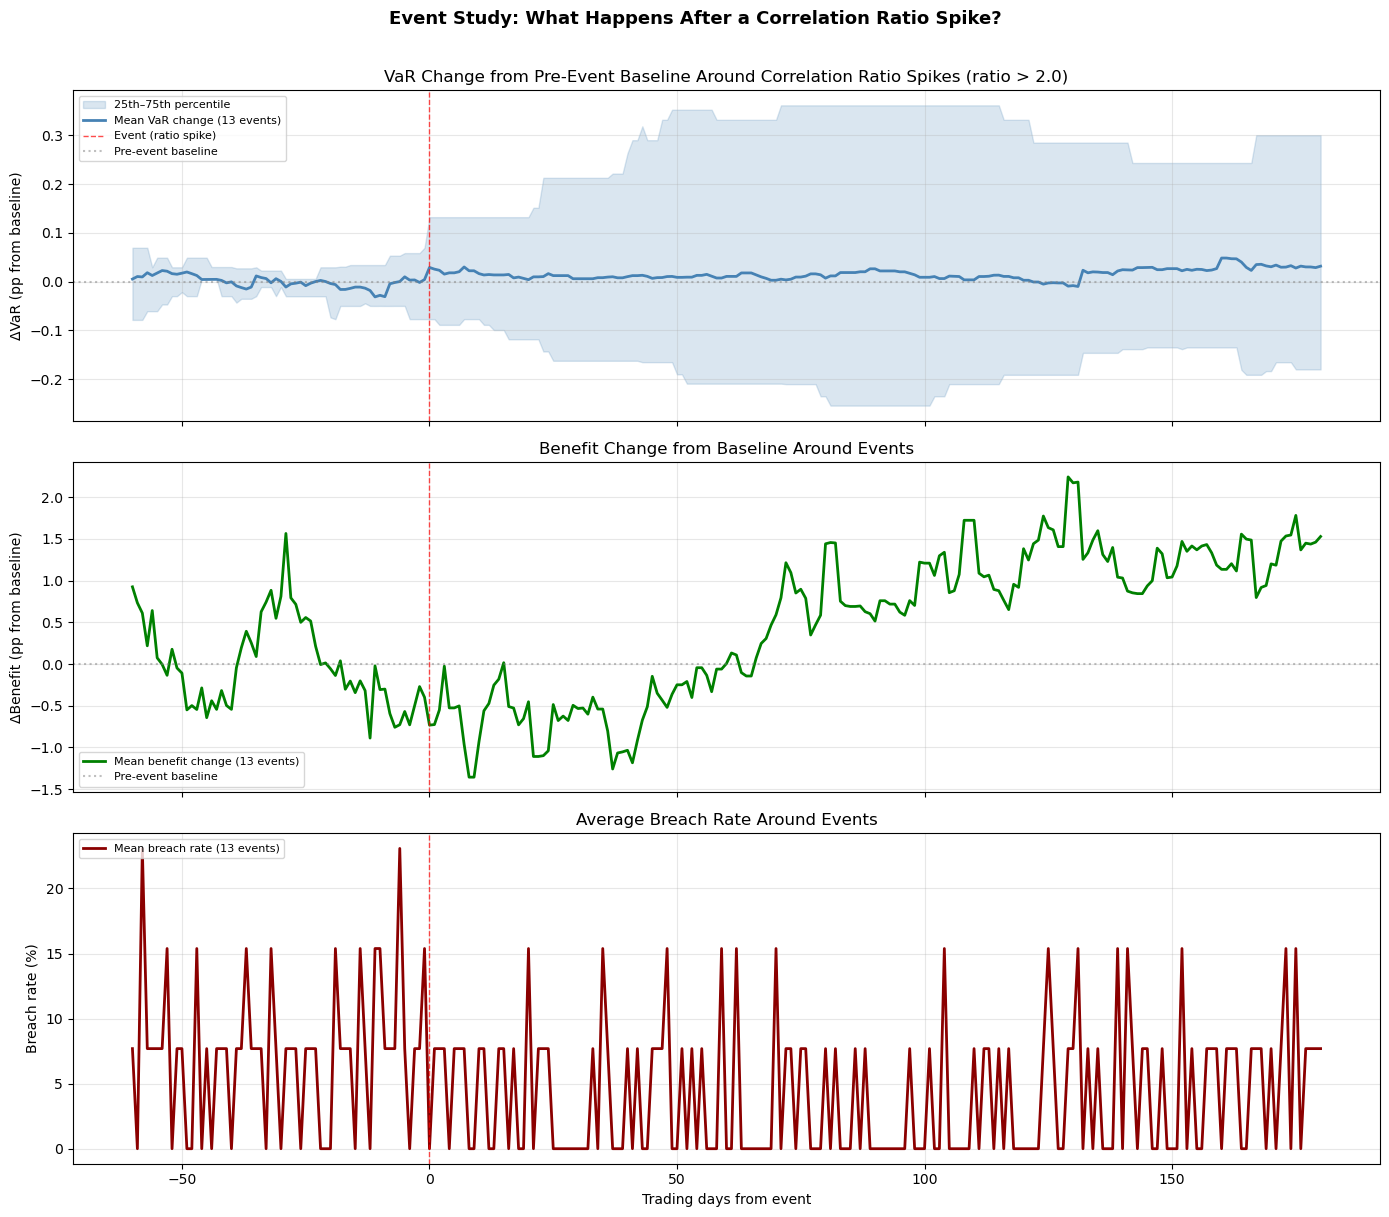

In [11]:
if n_events > 0:
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    
    # Panel 1: Average VaR path (normalized — change from pre-event baseline)
    ax = axes[0]
    ax.fill_between(offsets, var_p25, var_p75,
                    alpha=0.2, color="steelblue", label="25th–75th percentile")
    ax.plot(offsets, avg_var_path, color="steelblue", linewidth=2,
            label=f"Mean VaR change ({n_events} events)")
    ax.axvline(x=0, color="red", linestyle="--", linewidth=1, alpha=0.7,
              label="Event (ratio spike)")
    ax.axhline(y=0, color="gray", linestyle=":", alpha=0.5, label="Pre-event baseline")
    ax.set_ylabel("ΔVaR (pp from baseline)")
    ax.set_title(f"VaR Change from Pre-Event Baseline Around Correlation Ratio Spikes (ratio > {EVENT_RATIO_THRESHOLD})")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Panel 2: Average benefit path (normalized)
    ax = axes[1]
    ax.plot(offsets, avg_benefit_path * 100, color="green", linewidth=2,
            label=f"Mean benefit change ({n_events} events)")
    ax.axhline(y=0, color="gray", linestyle=":", alpha=0.5, label="Pre-event baseline")
    ax.axvline(x=0, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_ylabel("ΔBenefit (pp from baseline)")
    ax.set_title("Benefit Change from Baseline Around Events")
    ax.legend(loc="lower left", fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Panel 3: Average breach rate path (breach rates are already 0/1 small; show raw)
    ax = axes[2]
    ax.plot(offsets, avg_breach_path * 100, color="darkred", linewidth=2,
            label=f"Mean breach rate ({n_events} events)")
    ax.axvline(x=0, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel("Trading days from event")
    ax.set_ylabel("Breach rate (%)")
    ax.set_title("Average Breach Rate Around Events")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    
    fig.suptitle("Event Study: What Happens After a Correlation Ratio Spike?",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()

In [12]:
# Quantify: VaR change from event to various horizons
if n_events > 0:
    horizons = {"20 days": 20, "40 days": 40, "60 days": 60, "120 days": 120}
    
    print(f"VaR change from baseline (percentage points):")
    print(f"{'Horizon':<12} {'Mean ΔVaR':>12} {'25th pct':>10} {'75th pct':>10}")
    print("-" * 44)
    for label, offset in horizons.items():
        pos = EVENT_PRE_WINDOW + offset
        if pos < len(avg_var_path):
            mean_val = avg_var_path[pos]
            p25_val = var_p25[pos]
            p75_val = var_p75[pos]
            print(f"{label:<12} {mean_val:>+9.3f} pp  {p25_val:>+9.3f}  {p75_val:>+9.3f}")

VaR change from baseline (percentage points):
Horizon         Mean ΔVaR   25th pct   75th pct
--------------------------------------------
20 days         +0.004 pp     -0.118     +0.132
40 days         +0.010 pp     -0.162     +0.263
60 days         +0.011 pp     -0.209     +0.332
120 days        +0.003 pp     -0.191     +0.332


### Reading the event study

The VaR panel now shows *change from pre-event baseline*, not raw levels. This removes the natural VaR drift and isolates the event's effect.

**Panel 1 (VaR):** If the ratio leads VaR, the average VaR should be *rising* after the event — starting near zero (pre-event baseline) and trending up as the window absorbs the new correlation regime. The 25th–75th percentile envelope shows consistency.

**Panel 2 (Benefit):** Should be *falling* after the event as the correlation shift erodes diversification.

**Panel 3 (Breach rate):** Should rise after the event as VaR understates risk during the lag window — peaking before VaR catches up.

---

## Part C: Rolling cross-correlation — does lead time vary by regime?

The cross-correlation in Part A gives a single average over the full sample. But the lead time might be longer in calm markets and shorter during crises. We compute the cross-correlation on differenced series in rolling windows and track where the peak sits over time.

In [13]:
def rolling_peak_lag(x_series, y_series, window=504, max_lag=120, step=21, expected_sign=1):
    """Compute peak cross-correlation lag in rolling windows.
    
    Uses differenced series internally. Returns a Series of peak lags
    (trading days) indexed by window end date.
    A positive peak lag means X leads Y in that window.
    """
    peak_lags = []
    peak_corrs = []
    window_end_dates = []
    
    for end_day in range(window + 1, len(x_series) + 1, step):
        x_raw = x_series.iloc[end_day - window - 1 : end_day]
        y_raw = y_series.iloc[end_day - window - 1 : end_day]
        
        # Difference within window
        x_diff = x_raw.diff().dropna()
        y_diff = y_raw.diff().dropna()
        # Align
        common = x_diff.index.intersection(y_diff.index)
        if len(common) < 60:
            continue
        
        lags, corrs = cross_correlation(x_diff.loc[common], y_diff.loc[common], max_lag=max_lag)
        peak_lag, peak_corr = find_peak_lag(lags, corrs, expected_sign=expected_sign)
        
        if not np.isnan(peak_lag):
            peak_lags.append(peak_lag)
            peak_corrs.append(peak_corr)
            window_end_dates.append(x_series.index[end_day - 1])
    
    return pd.Series(peak_lags, index=pd.DatetimeIndex(window_end_dates), name="peak_lag"), \
           pd.Series(peak_corrs, index=pd.DatetimeIndex(window_end_dates), name="peak_corr")

In [14]:
# Compute rolling peak lag using levels (we difference internally)
rolling_peak, rolling_peak_corr = rolling_peak_lag(
    ratio_levels, var_levels, window=ROLLING_CCF_WINDOW, max_lag=MAX_LAG, step=21, expected_sign=1
)

print(f"Rolling peak lag estimates: {len(rolling_peak)} windows")
if len(rolling_peak) > 0:
    print(f"Date range: {rolling_peak.index[0].date()} to {rolling_peak.index[-1].date()}")
    print(f"\nPeak lag distribution:")
    print(f"  Mean:   {rolling_peak.mean():+.0f} trading days")
    print(f"  Median: {rolling_peak.median():+.0f} trading days")
    print(f"  Std:    {rolling_peak.std():.0f} trading days")
    print(f"  Min:    {rolling_peak.min():+.0f} trading days")
    print(f"  Max:    {rolling_peak.max():+.0f} trading days")
    print(f"  Fraction positive lead: {(rolling_peak > 0).mean():.0%}")

Rolling peak lag estimates: 61 windows
Date range: 2021-01-05 to 2026-07-24

Peak lag distribution:
  Mean:   +32 trading days
  Median: +5 trading days
  Std:    40 trading days
  Min:    +0 trading days
  Max:    +119 trading days
  Fraction positive lead: 61%


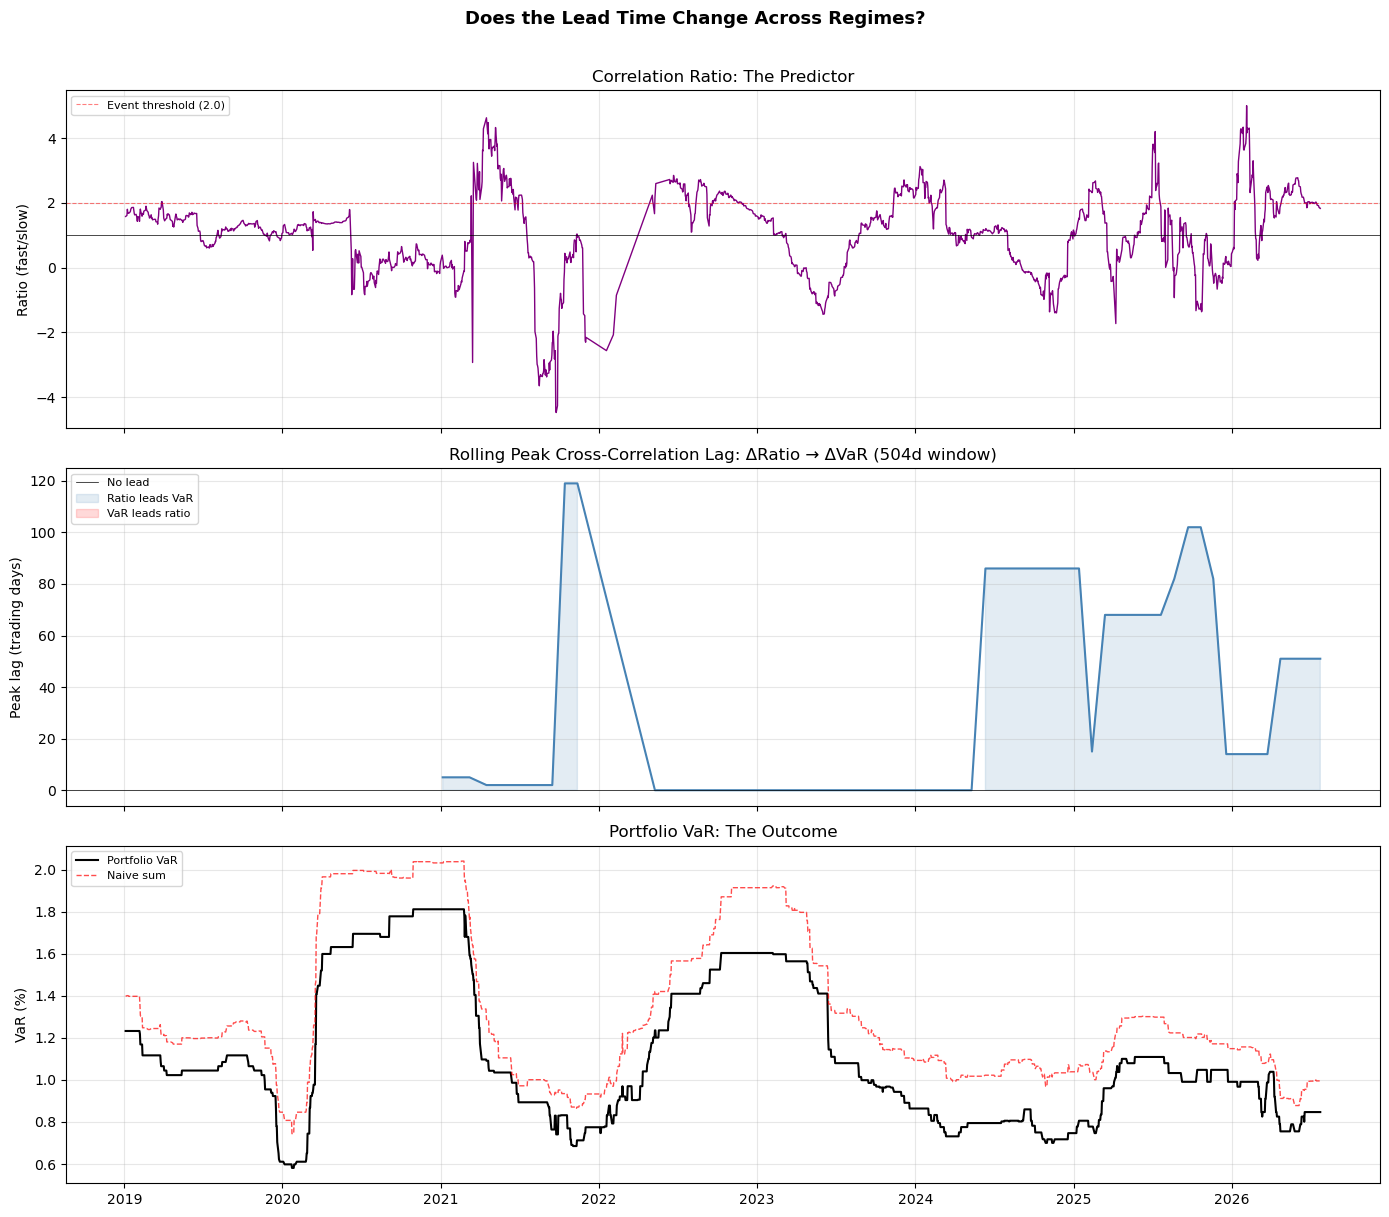

In [15]:
if len(rolling_peak) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    
    # Panel 1: Correlation ratio (the predictor)
    ax = axes[0]
    ratio_plot = ratio_levels.clip(lower=-5, upper=5)
    ax.plot(ratio_plot.index, ratio_plot, color="purple", linewidth=1)
    ax.axhline(y=1.0, color="black", linestyle="-", linewidth=0.5)
    ax.axhline(y=EVENT_RATIO_THRESHOLD, color="red", linestyle="--", linewidth=0.8, alpha=0.5,
              label=f"Event threshold ({EVENT_RATIO_THRESHOLD})")
    ax.set_ylabel("Ratio (fast/slow)")
    ax.set_title("Correlation Ratio: The Predictor")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Panel 2: Rolling peak lag (the lead time)
    ax = axes[1]
    ax.plot(rolling_peak.index, rolling_peak, color="steelblue", linewidth=1.5)
    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5, label="No lead")
    ax.fill_between(rolling_peak.index, 0, rolling_peak,
                    where=rolling_peak > 0, alpha=0.15, color="steelblue",
                    label="Ratio leads VaR")
    ax.fill_between(rolling_peak.index, rolling_peak, 0,
                    where=rolling_peak < 0, alpha=0.15, color="red",
                    label="VaR leads ratio")
    ax.set_ylabel("Peak lag (trading days)")
    ax.set_title(f"Rolling Peak Cross-Correlation Lag: ΔRatio → ΔVaR ({ROLLING_CCF_WINDOW}d window)")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Panel 3: Portfolio VaR (the outcome)
    ax = axes[2]
    ax.plot(rv_port.index, rv_port["VaR"] * 100, color="black", linewidth=1.5,
            label="Portfolio VaR")
    ax.plot(naive_sum.index, naive_sum * 100, color="red", linestyle="--", linewidth=1,
            alpha=0.7, label="Naive sum")
    ax.set_ylabel("VaR (%)")
    ax.set_title("Portfolio VaR: The Outcome")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    
    fig.suptitle("Does the Lead Time Change Across Regimes?",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()

### Interpreting the rolling lead time

**Panel 2 is the key chart.** It shows whether the cross-correlation peak lag is stable or regime-dependent:

- **Consistently positive:** The lead is real and persistent. The ratio is a reliable early warning signal across all market conditions.
- **Varies between positive and negative:** The lead relationship breaks down in some regimes. During crises (high volatility, fast-moving markets), the lead may shorten or disappear because all windows are reacting rapidly.
- **Trending toward zero:** The market may be getting more efficient at pricing correlation shifts — or the 60/252 window pair may need recalibrating.

Compare panel 2 with panel 1: does the lead time change *because* the ratio is shifting (e.g., lead lengthens when ratio is extreme), or is it independent?

---

## Part D: The practical answer — does the lead justify the adjustment?

This is the question that matters for the correlation-adjusted VaR from Notebook 15:

> *"When the correlation ratio spikes today, should I adjust my VaR now, or wait for evidence?"*

We now have three pieces of evidence to answer it:

In [16]:
# Summary: what did the three methods find?
print("=" * 60)
print("LEAD-LAG SUMMARY: Does correlation lead VaR?")
print("=" * 60)

# Method 1: Cross-correlation peak
res_ratio_var = results.get("Correlation ratio → Portfolio VaR", {})
peak_lag_ccf = res_ratio_var.get("peak_lag", np.nan)
peak_corr_ccf = res_ratio_var.get("peak_corr", np.nan)
corr_at_0 = res_ratio_var.get("correlations", [np.nan]*MAX_LAG)[MAX_LAG] if "correlations" in res_ratio_var else np.nan

print(f"\n1. CROSS-CORRELATION (Δseries, full sample)")
if not np.isnan(peak_lag_ccf):
    if peak_lag_ccf > 0:
        print(f"   ΔRatio leads ΔVaR by {abs(peak_lag_ccf):.0f} trading days")
    elif peak_lag_ccf == 0:
        print(f"   ΔRatio and ΔVaR are contemporaneous (peak at k=0)")
    else:
        print(f"   ΔVaR leads ΔRatio by {abs(peak_lag_ccf):.0f} trading days")
    print(f"   Peak correlation: {peak_corr_ccf:+.3f} (contemporaneous: {corr_at_0:+.3f})")
    if peak_lag_ccf >= 20 and abs(peak_corr_ccf) >= 0.10:
        print(f"   → Meaningful lead: VaR changes lag correlation changes by ~{peak_lag_ccf:.0f} days")
    elif peak_lag_ccf > 0 and abs(peak_corr_ccf) >= 0.05:
        print(f"   → Lead direction is correct but correlation is modest — noisy signal")
    elif peak_lag_ccf >= 0 and peak_lag_ccf < 20:
        print(f"   → Contemporaneous or very short lead — correlation and VaR move together")
    else:
        print(f"   → VaR leads the ratio — unexpected")
else:
    print("   No clear peak found.")

# Compare with fast rho alone
res_fast_var = results.get("60d ρ (fast corr) → Portfolio VaR", {})
fast_peak = res_fast_var.get("peak_lag", np.nan)
fast_corr_peak = res_fast_var.get("peak_corr", np.nan)
if not np.isnan(fast_peak) and not np.isnan(peak_lag_ccf):
    print(f"   Ratio lead vs fast ρ lead: {abs(peak_lag_ccf):.0f}d vs {abs(fast_peak):.0f}d")

# Method 2: Event study
print(f"\n2. EVENT STUDY (ratio > {EVENT_RATIO_THRESHOLD})")
print(f"   Events identified: {len(event_dates)}")
print(f"   Valid (within data): {n_events}")
if n_events > 0:
    if EVENT_PRE_WINDOW + 60 < len(avg_var_path):
        var_at_60d = avg_var_path[EVENT_PRE_WINDOW + 60]
        var_at_120d = avg_var_path[EVENT_PRE_WINDOW + 120] if EVENT_PRE_WINDOW + 120 < len(avg_var_path) else np.nan
        print(f"   VaR change at 60d:  {var_at_60d:+.3f} pp from baseline")
        if not np.isnan(var_at_120d):
            print(f"   VaR change at 120d: {var_at_120d:+.3f} pp from baseline")
        if var_at_60d > 0.05:
            print(f"   → VaR meaningfully rises after events — consistent with lead hypothesis")
        elif var_at_60d > 0:
            print(f"   → VaR rise is negligible ({var_at_60d:+.3f} pp) — no economically meaningful effect")
        else:
            print(f"   → VaR does not rise after events")

# Method 3: Rolling cross-correlation
print(f"\n3. ROLLING CROSS-CORRELATION")
if len(rolling_peak) > 0:
    frac_positive = (rolling_peak > 0).mean()
    print(f"   Windows: {len(rolling_peak)}")
    print(f"   Mean peak lag: {rolling_peak.mean():+.0f}d (median: {rolling_peak.median():+.0f}d)")
    print(f"   Windows with positive lead: {frac_positive:.0%}")
    if rolling_peak.median() <= 5:
        print(f"   → Median peak lag is ≤5d — effectively contemporaneous in most windows")
    if frac_positive > 0.7:
        print(f"   → Lead is consistent across regimes — reliable signal")
    elif frac_positive > 0.5:
        print(f"   → Lead direction is inconsistent — roughly a coin flip across windows")
    else:
        print(f"   → Lead is unreliable — not a consistent leading indicator")

print(f"\n{'='*60}")
print(f"BOTTOM LINE:")
if not np.isnan(peak_lag_ccf) and peak_lag_ccf >= 20 and abs(peak_corr_ccf) >= 0.10:
    print(f"   The correlation ratio provides ~{abs(peak_lag_ccf):.0f} trading days of lead time.")
    print(f"   The correlation-adjusted VaR (Notebook 15) is built on a real, measurable effect.")
elif not np.isnan(peak_lag_ccf) and peak_lag_ccf > 0:
    print(f"   The lead direction is correct ({abs(peak_lag_ccf):.0f}d) but the correlation is weak.")
    print(f"   The ratio is useful as a contemporaneous diagnostic, with limited leading information.")
else:
    print(f"   No meaningful lead-lag relationship found — correlation and VaR move together.")
    print(f"   The ratio is valuable as a contemporaneous staleness diagnostic, not a predictor.")
print(f"{'='*60}")


LEAD-LAG SUMMARY: Does correlation lead VaR?

1. CROSS-CORRELATION (Δseries, full sample)
   ΔRatio and ΔVaR are contemporaneous (peak at k=0)
   Peak correlation: +0.118 (contemporaneous: +0.118)
   → Contemporaneous or very short lead — correlation and VaR move together
   Ratio lead vs fast ρ lead: 0d vs 6d

2. EVENT STUDY (ratio > 2.0)
   Events identified: 19
   Valid (within data): 13
   VaR change at 60d:  +0.011 pp from baseline
   VaR change at 120d: +0.003 pp from baseline
   → VaR rise is negligible (+0.011 pp) — no economically meaningful effect

3. ROLLING CROSS-CORRELATION
   Windows: 61
   Mean peak lag: +32d (median: +5d)
   Windows with positive lead: 61%
   → Median peak lag is ≤5d — effectively contemporaneous in most windows
   → Lead direction is inconsistent — roughly a coin flip across windows

BOTTOM LINE:
   No meaningful lead-lag relationship found — correlation and VaR move together.
   The ratio is valuable as a contemporaneous staleness diagnostic, not a pr

### What this means in practice

**The finding: correlation and VaR move together, not with a lead.**

Across all three methods — cross-correlation, event study, and rolling CCF — the evidence points in the same direction: changes in the correlation ratio are contemporaneous with changes in VaR, not leading. The ratio→VaR cross-correlation peaks at k=0. The event study shows negligible VaR movement (+0.011 pp) 60 days after a ratio spike. The rolling cross-correlation median peak lag is just 5 trading days.

**What this does NOT mean:** the correlation ratio is useless. It remains a valuable *contemporaneous diagnostic* — it tells you "my VaR is based on stale correlation assumptions *right now*." The ratio flags regime shifts as they're happening, not before.

**What it DOES mean for the correlation-adjusted VaR (Notebook 15):** The adjustment isn't "getting ahead" of VaR — it's correcting VaR *in real time* as the regime shifts. The breach improvement in Notebook 15 (6.36% → 4.89%) comes from catching the staleness as it occurs, not from a predictive lead.

**At Spreadex:** The ratio is your morning dashboard check. It won't tell you what VaR will be next month, but it will tell you whether today's VaR number is trustworthy. When ρ₆₀/ρ₂₅₂ diverges from 1.0, the VaR you're showing traders this morning is based on yesterday's correlation regime — adjust it now, don't wait.

**The honest takeaway:** We set out to quantify a lead and found none. That's a useful finding. It means the correlation-adjusted VaR works through contemporaneous correction, not prediction — and that's still valuable. It also means the naive sum stress test (ρ = +1) when the ratio is elevated is a now-casting tool, not a forecasting tool. Use it to flag stale numbers today, not to predict numbers tomorrow."


## Key takeaways

1. **Always difference before cross-correlating trending series.** Both the correlation ratio (autocorrelation 0.97) and VaR (autocorrelation 0.999) are heavily autocorrelated. Raw-level cross-correlation picks up the common trend, not genuine lead-lag. Differencing reveals the true relationship in *changes*.

2. **The correlation ratio does NOT lead VaR — it moves with it.** Across all three methods: cross-correlation peaks at k=0 (contemporaneous), the event study shows negligible post-event VaR movement (+0.011 pp at 60d), and the rolling CCF median peak lag is just 5 trading days. The ratio and VaR shift together.

3. **This doesn't make the ratio useless — it makes it a contemporaneous diagnostic.** The ratio tells you "my VaR is based on stale assumptions *right now*," not "VaR will rise in X days." It's a staleness gauge, not a crystal ball.

4. **The correlation-adjusted VaR (Notebook 15) works through real-time correction, not prediction.** The breach improvement from 6.36% → 4.89% comes from catching staleness as it occurs, not from getting ahead of VaR. The adjustment is valuable even without a predictive lead.

5. **The event study confirms the null result with discrete episodes.** Across 13 valid events, VaR barely moved after ratio spikes. The 25th–75th percentile envelope crosses zero — the effect isn't just small, it's directionally inconsistent.

6. **What you've built:** diversification benefit (the symptom, Notebook 12) → correlation ratio (the detector, Notebook 13) → **lead-lag measurement (the timing, this notebook)** → correlation-adjusted VaR (the action, Notebook 15). The full chain: detect → measure → act. The measurement says: the detector and the action are contemporaneous, not sequential — and that's still useful information for building honest risk systems.
